# 🕵️ Email Spam Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
c = pd.read_csv('completeSpamAssassin.csv')
e = pd.read_csv('enronSpamSubset.csv')
l = pd.read_csv('lingSpam.csv')

In [3]:
c.head()

,Unnamed: 0,Body,Label
0,0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1
1,1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
2,2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
3,3,##############################################...,1
4,4,I thought you might like these:\n1) Slim Down ...,1


In [4]:
print('Null Values','\n')
print(c.isnull().sum())
print('\n','Is duplicated')
print(c.duplicated().sum())

Null Values 

Unnamed: 0    0
Body          1
Label         0
dtype: int64

 Is duplicated
0


In [5]:
e.head()

,Unnamed: 0.1,Unnamed: 0,Body,Label
0,2469,2469,Subject: stock promo mover : cwtd\n * * * urge...,1
1,5063,5063,Subject: are you listed in major search engine...,1
2,12564,12564,"Subject: important information thu , 30 jun 20...",1
3,2796,2796,Subject: = ? utf - 8 ? q ? bask your life with...,1
4,1468,1468,"Subject: "" bidstogo "" is places to go , things...",1


In [6]:
print('Null Values','\n')
print(e.isnull().sum())
print('\n','Is duplicated')
print(e.duplicated().sum())

Null Values 

Unnamed: 0.1    0
Unnamed: 0      0
Body            0
Label           0
dtype: int64

 Is duplicated
0


In [7]:
l.head()

,Unnamed: 0,Body,Label
0,0,Subject: great part-time or summer job !\n \n ...,1
1,1,Subject: auto insurance rates too high ?\n \n ...,1
2,2,Subject: do want the best and economical hunti...,1
3,3,Subject: email 57 million people for $ 99\n \n...,1
4,4,Subject: do n't miss these !\n \n attention ! ...,1


In [8]:
print('Null Values','\n')
print(l.isnull().sum())
print('\n','Is duplicated')
print(l.duplicated().sum())

Null Values 

Unnamed: 0    0
Body          0
Label         0
dtype: int64

 Is duplicated
0


# Data Cleaning

In [9]:
c.drop(columns=['Unnamed: 0'],axis=1,inplace=True)
e.drop(columns=['Unnamed: 0.1','Unnamed: 0'],axis=1,inplace=True)
l.drop(columns=['Unnamed: 0'],axis=1,inplace=True)

In [10]:
df = pd.concat((c,e,l),axis=0)

In [11]:
df

,Body,Label
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
3,##############################################...,1
4,I thought you might like these:\n1) Slim Down ...,1
...,...,...
2600,Subject: computationally - intensive methods i...,0
2601,Subject: books : a survey of american linguist...,0
2602,Subject: wecol ' 98 - - western conference on ...,0
2603,Subject: euralex ' 98 - revised programme\n \n...,0


In [12]:
df = df[~df['Body'].isna()]

In [13]:
df

,Body,Label
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
3,##############################################...,1
4,I thought you might like these:\n1) Slim Down ...,1
...,...,...
2600,Subject: computationally - intensive methods i...,0
2601,Subject: books : a survey of american linguist...,0
2602,Subject: wecol ' 98 - - western conference on ...,0
2603,Subject: euralex ' 98 - revised programme\n \n...,0


In [14]:
df = df.drop_duplicates(keep = 'first')

In [15]:
df.shape

(17571, 2)

# EDA

In [16]:
df.head()

,Body,Label
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
3,##############################################...,1
4,I thought you might like these:\n1) Slim Down ...,1


In [17]:
df['Label'].value_counts()

Label
0    11010
1     6561
Name: count, dtype: int64

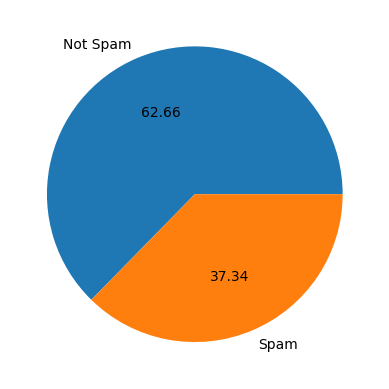

In [18]:
plt.pie(df['Label'].value_counts(),labels=['Not Spam','Spam'],autopct="%0.2f")
plt.show()

In [19]:
import nltk

In [20]:
df['num_char'] = df['Body'].apply(len)

In [21]:
df.head()

,Body,Label,num_char
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1,1111
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,753
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,610
3,##############################################...,1,2863
4,I thought you might like these:\n1) Slim Down ...,1,641


In [22]:
df['num_word'] = df['Body'].apply(lambda x:len(nltk.word_tokenize(x)))

In [23]:
df.head()

,Body,Label,num_char,num_word
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1,1111,191
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,753,139
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,610,113
3,##############################################...,1,2863,690
4,I thought you might like these:\n1) Slim Down ...,1,641,108


In [24]:
df['num_sent'] = df['Body'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [25]:
df.head()

,Body,Label,num_char,num_word,num_sent
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1,1111,191,12
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,753,139,5
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,610,113,4
3,##############################################...,1,2863,690,35
4,I thought you might like these:\n1) Slim Down ...,1,641,108,4


In [26]:
df[['num_char','num_word','num_sent']].describe()

,num_char,num_word,num_sent
count,1.757100e+04,1.757100e+04,17571.000000
mean,2.883105e+03,5.877590e+02,33.432246
std,1.289535e+05,2.734452e+04,1684.898373
min,1.000000e+00,0.000000e+00,0.000000
25%,4.470000e+02,9.000000e+01,5.000000
50%,9.320000e+02,1.890000e+02,10.000000
75%,1.973000e+03,3.960000e+02,19.000000
max,1.708563e+07,3.623500e+06,223247.000000


# Compare with Labels 

In [27]:
df[df['Label'] == 1][['num_char','num_word','num_sent']].describe()

,num_char,num_word,num_sent
count,6561.000000,6561.000000,6561.000000
mean,1721.530407,340.959610,21.006859
std,3478.995953,635.228979,54.576377
min,1.000000,0.000000,0.000000
25%,416.000000,83.000000,6.000000
50%,783.000000,159.000000,10.000000
75%,1695.000000,331.000000,20.000000
max,129635.000000,13292.000000,3093.000000


In [28]:
df[df['Label'] == 0][['num_char','num_word','num_sent']].describe()

,num_char,num_word,num_sent
count,1.101000e+04,1.101000e+04,11010.000000
mean,3.575302e+03,7.348300e+02,40.836694
std,1.628830e+05,3.454045e+04,2128.107362
min,5.000000e+00,1.000000e+00,1.000000
25%,4.810000e+02,9.700000e+01,5.000000
50%,1.034000e+03,2.120000e+02,9.000000
75%,2.084000e+03,4.230000e+02,19.000000
max,1.708563e+07,3.623500e+06,223247.000000


# Visualisation

## Relationship btw columns with target columns

<Axes: >

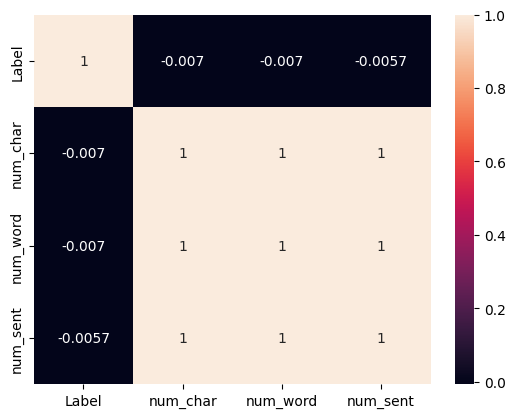

In [29]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# EDA (Exploratory Data Analysis)

In [30]:
df.head()

,Body,Label,num_char,num_word,num_sent
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1,1111,191,12
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,753,139,5
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,610,113,4
3,##############################################...,1,2863,690,35
4,I thought you might like these:\n1) Slim Down ...,1,641,108,4


In [31]:
df['Body'][0]

0    \nSave up to 70% on Life Insurance.\nWhy Spend...
0    Subject: stock promo mover : cwtd\n * * * urge...
0    Subject: great part-time or summer job !\n \n ...
Name: Body, dtype: object

In [32]:
# Stopwords are: High-frequency words that often don’t help distinguish between classes.
# Ex:- "You are not selected" , If you remove stopwords: we get only "selected"

# ps = PorterStemmer() comes from NLTK.
# It’s a stemming algorithm
# ps.stem(word):- It reduces a word to its root form (not perfect English root—just a crude base form).


In [18]:
def transformed_text(text):
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import PorterStemmer
    
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    
    text = text.lower()  # text into lower case
    words = nltk.word_tokenize(text) # Break the sentence in words in list.
                                     # each word is token.
    y = [] 
    for word in words:
        if word.isalnum() and word not in stop_words:
            y.append(ps.stem(word)) #Ex: running -> run
            # This reduces feature space and improves generalization.
    
    return " ".join(y)

In [34]:
transformed_text('''\n
Save up to 70% on Life Insurance.\n
Why Spend...
Subject: stock promo mover : cwtd
* * * urge...
Subject: great part-time or summer job !

... ''')

'save 70 life insur spend subject stock promo mover cwtd urg subject great summer job'

In [19]:
df['text_transformed'] = df['Body'].apply(transformed_text)

In [36]:
df.head()

,Body,Label,num_char,num_word,num_sent,text_transformed
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1,1111,191,12,save 70 life insur spend life quot save ensur ...
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,753,139,5,1 fight risk cancer http slim guarante lose lb...
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,610,113,4,1 fight risk cancer http slim guarante lose lb...
3,##############################################...,1,2863,690,35,adult club offer free membership instant acces...
4,I thought you might like these:\n1) Slim Down ...,1,641,108,4,thought might like 1 slim guarante lose lb 30 ...


In [37]:
from wordcloud import WordCloud
wc = WordCloud(width =500, height =500, min_font_size =10,background_color='white')

In [38]:
spam = wc.generate(df[df['Label']==1]['text_transformed'].str.cat(sep=" "))

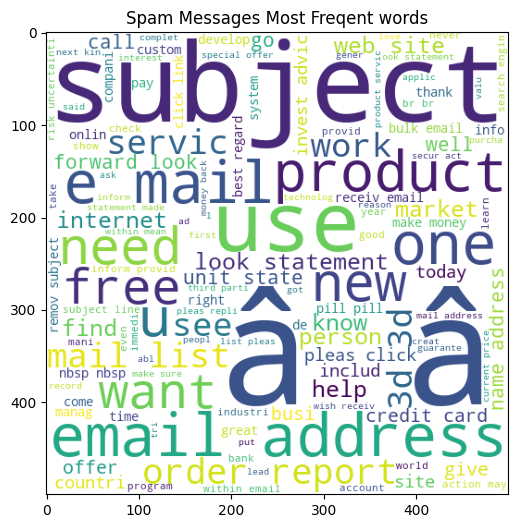

In [39]:
plt.figure(figsize=(12,6))
plt.title('Spam Messages Most Freqent words')
plt.imshow(spam)

In [40]:
ham = wc.generate(df[df['Label']==0]['text_transformed'].str.cat(sep=" "))

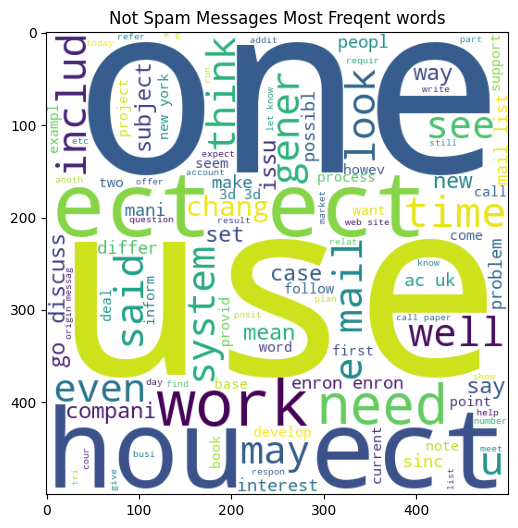

In [41]:
plt.figure(figsize=(12,6))
plt.title('Not Spam Messages Most Freqent words')
plt.imshow(ham)

In [42]:
spam_corpus = []
for msg in df[df['Label']==1]['text_transformed'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [43]:
len(spam_corpus)

1044426

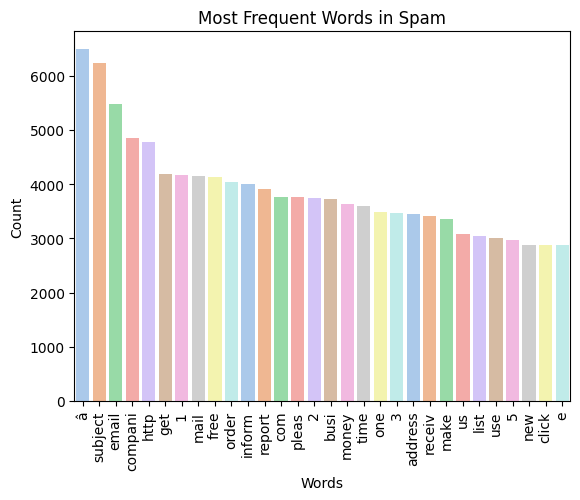

In [44]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette='pastel')
plt.xticks(rotation='vertical')
plt.title('Most Frequent Words in Spam')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

In [45]:
notspam_corpus = []
for msg in df[df['Label']==0]['text_transformed'].tolist():
    for word in msg.split():
        notspam_corpus.append(word)

In [46]:
len(notspam_corpus)

3594644

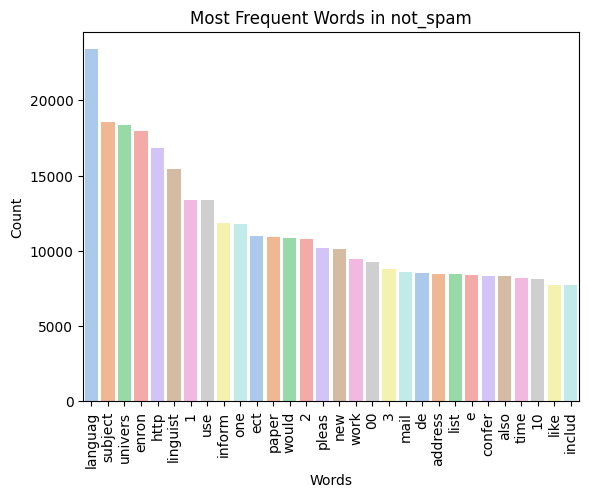

In [47]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(notspam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(notspam_corpus).most_common(30))[1],palette='pastel')
plt.xticks(rotation='vertical')
plt.title('Most Frequent Words in not_spam')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

# Text Vectorization

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [17]:
tfid = TfidfVectorizer(max_features=5000,ngram_range=(1,2))

In [131]:
X = tfid.fit_transform(df['text_transformed']).toarray()
X

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.10574766, 0.00371966, 0.00327429, ..., 0.00693237, 0.00073759,
        0.00470603]])

In [132]:
y = df['Label'].values
y

array([1, 1, 1, ..., 0, 0, 0], dtype=int64)

In [22]:
from sklearn.model_selection import train_test_split

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=32)

In [135]:
X_train.shape , y_train.shape

((14056, 5000), (14056,))

# Model Fitting

In [32]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
from sklearn.model_selection import cross_val_score

In [106]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [107]:
cl = {
    'gnb':gnb,
    'mnb':mnb,
    'bnb':bnb
}

In [108]:
def trainclassifier(cl,X_train, y_train, x_test, y_test):
    cl.fit(X_train,y_train)
    y_pred = cl.predict(X_test)
    acc_sco = accuracy_score(y_test, y_pred)
    pre_sco = precision_score(y_test, y_pred)

    return acc_sco , pre_sco

In [109]:
accuracy_scores = []
precision_scores = []

for name,clf in cl.items():
    
    current_accuracy,current_precision = trainclassifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  gnb
Accuracy -  0.8972972972972973
Precision -  0.8085390260173448
For  mnb
Accuracy -  0.9615931721194879
Precision -  0.943716268311488
For  bnb
Accuracy -  0.9177809388335704
Precision -  0.8264571054354944


In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [111]:
sv = SVC(kernel='sigmoid', gamma=1.0)
svc = LinearSVC()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [112]:
clfs = {
    'SVC' : svc,
    'Sv':sv,
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc,  
    'xgb':xgb,
}

In [113]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = trainclassifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9772403982930299
Precision -  0.9638461538461538
For  Sv
Accuracy -  0.9724039829302987
Precision -  0.9541634835752483
For  NB
Accuracy -  0.9615931721194879
Precision -  0.943716268311488
For  DT
Accuracy -  0.793172119487909
Precision -  0.6676664667066586
For  LR
Accuracy -  0.966145092460882
Precision -  0.9450800915331807
For  RF
Accuracy -  0.9675675675675676
Precision -  0.9556765163297045
For  xgb
Accuracy -  0.9607396870554765
Precision -  0.9328808446455505


# Evaluate The Simple Model

In [117]:
# LogisticRegression

from sklearn.model_selection import cross_val_score

scores = cross_val_score(lrc, X, y, cv=5, scoring='f1')
print('LogisticReg')
print(scores)
print(scores.mean())

LogisticReg
[0.8871939  0.92307692 0.94188226 0.9505988  0.84901828]
0.9103540337039725


In [115]:
# LinearSVC

scores = cross_val_score(svc,x, y, cv=5, scoring='f1')

print('LinearSVC')
print("Scores:", scores)
print("Mean F1:", scores.mean())
print()

LinearSVC
Scores: [0.91889794 0.93162706 0.96293495 0.96981132 0.87047354]
Mean F1: 0.9307489610853666



In [119]:
svc.fit(X_train,y_train)
y_pred3 = svc.predict(X_test) 

In [121]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print('LinearSVC','\n')
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3))
print("Recall:", recall_score(y_test, y_pred3))
print("F1 Score:", f1_score(y_test, y_pred3))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred3))

print("\nClassification Report")
print(classification_report(y_test, y_pred3))

LinearSVC 

Accuracy: 0.9772403982930299
Precision: 0.9638461538461538
Recall: 0.9743390357698289
F1 Score: 0.9690641918020109

Confusion Matrix
[[2182   47]
 [  33 1253]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2229
           1       0.96      0.97      0.97      1286

    accuracy                           0.98      3515
   macro avg       0.97      0.98      0.98      3515
weighted avg       0.98      0.98      0.98      3515



# Model Pipeline

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
import joblib

In [23]:
x_train, x_test, Y_train, Y_test = train_test_split(df['text_transformed'],df['Label'],test_size=0.2,random_state=42)

In [24]:
x_train.shape, Y_train.shape

((14056,), (14056,))

In [25]:
base_svc = LinearSVC()

calibrated_svc = CalibratedClassifierCV(estimator=base_svc, method='sigmoid', cv=5)

In [26]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2)
    )),
    ('classifier', calibrated_svc)
])

In [28]:
pipeline.fit(x_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [29]:
y_pred2 = pipeline.predict(x_test)

In [30]:
joblib.dump(pipeline, 'spam_pipeline.pkl')

['spam_pipeline.pkl']

In [33]:
print("Accuracy:", accuracy_score(Y_test, y_pred2))
print("Precision:", precision_score(Y_test, y_pred2))

Accuracy: 0.9786628733997155
Precision: 0.9728506787330317


## Predict

In [171]:
pipeline.predict([df['Body'].iloc[2602]])

array([0], dtype=int64)

In [170]:
df

,Body,Label,num_char,num_word,num_sent,text_transformed
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1,1111,191,12,save 70 life insur spend life quot save ensur ...
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,753,139,5,1 fight risk cancer http slim guarante lose lb...
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,610,113,4,1 fight risk cancer http slim guarante lose lb...
3,##############################################...,1,2863,690,35,adult club offer free membership instant acces...
4,I thought you might like these:\n1) Slim Down ...,1,641,108,4,thought might like 1 slim guarante lose lb 30 ...
...,...,...,...,...,...,...
2600,Subject: computationally - intensive methods i...,0,3446,572,29,subject comput intens method quantit linguist ...
2601,Subject: books : a survey of american linguist...,0,2627,469,26,subject book survey american linguist publish ...
2602,Subject: wecol ' 98 - - western conference on ...,0,818,159,15,subject wecol 98 western confer linguist arizo...
2603,Subject: euralex ' 98 - revised programme\n \n...,0,497,106,11,subject euralex 98 revis programm euralex 98 l...
